# IoT Traffic Analysis v8 — Summary-only behavioral windows (UNSW/Dryad)

This notebook implements **v8 (summary-only)** for IoT device **type** classification using the Dryad/UNSW IoT PCAPs.

## What this version does
- Extracts **window-level behavioral summaries** from packet streams.
- Trains a simple **MLP** (no packet-sequence CNN/Transformer).
- Uses **device-level train/test split** (generalization to unseen devices).
- Reports **window-level** and **device-level (aggregated)** metrics.

This is designed to be the clean baseline for later v8 variants:
- packet + summary (two-branch)
- summary + no direction


In [4]:
# If running in a fresh environment, install deps as needed:
# !pip install scapy tensorflow scikit-learn pandas numpy matplotlib

import os
import math
import random
import numpy as np
import pandas as pd

from scapy.all import PcapReader
from scapy.layers.inet import IP, TCP, UDP, ICMP

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## 1) Dataset location
Set `PCAP_DIR` to the folder where you extracted `pcaps.zip` from the Dryad dataset.

Expected structure:
- `PCAP_DIR/*.pcap`


In [5]:
# === UPDATE THIS PATH ===
PCAP_DIR = "unsw-dataset/pcaps"   # e.g. "/content/pcaps" or "./pcaps"

assert os.path.isdir(PCAP_DIR), f"PCAP_DIR not found: {PCAP_DIR}"
pcap_files = sorted([os.path.join(PCAP_DIR, f) for f in os.listdir(PCAP_DIR) if f.endswith(".pcap")])

print("PCAP count:", len(pcap_files))
print("Example:", pcap_files[:3])


PCAP count: 26
Example: ['unsw-dataset/pcaps/AmazonEcho_44650d56ccd3.pcap', 'unsw-dataset/pcaps/AugustDoorBell_e076d03f00ae.pcap', 'unsw-dataset/pcaps/AwairAirQuality_70886b100fc6.pcap']


## 2) v8 device-type taxonomy + mapping

### v8 labels (recommended for this dataset)
- `continuous_streaming`
- `low_rate_telemetry`
- `interactive_actuators`
- `smart_media_clients`

By default we **exclude** the `hub_gateway_bridge` devices (not learnable here: only 2 devices and behavior is not coherent).


In [6]:
from collections import Counter

device_to_type_v7 = {
    "SamsungCamera_00166cab6b88": "camera_streamer",
    "BelkinCamera_b4750eece5a9": "camera_streamer",
    "NestDropCam_308cfb2fe4b2": "camera_streamer",
    "TPLinkCamera_f4f26D9351f1": "camera_streamer",
    "CanaryCamera_7c70bc5d5edc": "camera_streamer",
    "NetatmoWelcome_70ee50183443": "camera_streamer",
    "WithingsBabyMonitor_0024e41118a8": "camera_streamer",
    "RingDoorBell_884aea31669d": "camera_streamer",
    "AugustDoorBell_e076d03f00ae": "camera_streamer",

    "AwairAirQuality_70886b100fc6": "sensor_meter",
    "NetatmoWeatherStation_70ee5003b8ac": "sensor_meter",
    "WithingsSleepSensor_0024e42028c6": "sensor_meter",
    "WithingsSmartScale_0024e41b6f96": "sensor_meter",
    "BlipCareBPMeter_746a89002e25": "sensor_meter",
    "NestProtect_18b43025bee4": "sensor_meter",
    "BelkinWemoMotionSensor_ec1a59832811": "sensor_meter",

    "PhilipsHue_0017882b9a25": "actuator_light_plug",
    "LiFXBulb_d073d5018308": "actuator_light_plug",
    "TPLinkSmartPlug_50c7bf005639": "actuator_light_plug",
    "BelkinWemoSwitch_ec1a5979f489": "actuator_light_plug",

    "SamsungSmartThings_d052a800675e": "hub_gateway_bridge",
    "HPPrinter_705a0fe49bc0": "hub_gateway_bridge",

    "TribySpeaker_18B79E022044": "media_speaker_display",
    "PixStarPhotoFrame_e076d033bb85": "media_speaker_display",
    "HelloBarbie_28c2ddffa52d": "media_speaker_display",
    "iHome_74c63b29d71d": "media_speaker_display",
    "AmazonEcho_44650d56ccd3": "media_speaker_display",
}

v7_to_v8 = {
    "camera_streamer": "continuous_streaming",
    "sensor_meter": "low_rate_telemetry",
    "actuator_light_plug": "interactive_actuators",
    "media_speaker_display": "smart_media_clients",
    "hub_gateway_bridge": None,  # excluded
}

device_to_type_v8 = {dev: v7_to_v8.get(t, None) for dev, t in device_to_type_v7.items()}

DROP_NONE_TYPES = True

target_types = sorted([t for t in set(device_to_type_v8.values()) if t is not None])
print("v8 target types:", target_types)
print("Counts:", Counter([t for t in device_to_type_v8.values() if t is not None]))


v8 target types: ['continuous_streaming', 'interactive_actuators', 'low_rate_telemetry', 'smart_media_clients']
Counts: Counter({'continuous_streaming': 9, 'low_rate_telemetry': 7, 'smart_media_clients': 5, 'interactive_actuators': 4})


## 3) Build device table from PCAPs
We match each PCAP filename (without `.pcap`) to your `device_to_type_v8` mapping.
If your filenames differ, adjust `device_id_from_path()`.


In [7]:
def device_id_from_path(pcap_path: str) -> str:
    base = os.path.basename(pcap_path)
    return base.replace(".pcap", "")

rows = []
for p in pcap_files:
    dev = device_id_from_path(p)
    v8_type = device_to_type_v8.get(dev, None)
    if DROP_NONE_TYPES and v8_type is None:
        continue
    if v8_type is None:
        v8_type = "unknown_infrastructure"
    rows.append({"device_id": dev, "device_type": v8_type, "pcap_path": p})

df_dev = pd.DataFrame(rows).sort_values(["device_type", "device_id"]).reset_index(drop=True)
print("Devices included:", len(df_dev))
display(df_dev.head(10))
print(df_dev["device_type"].value_counts())


Devices included: 23


,device_id,device_type,pcap_path
0,AugustDoorBell_e076d03f00ae,continuous_streaming,unsw-dataset/pcaps/AugustDoorBell_e076d03f00ae...
1,BelkinCamera_b4750eece5a9,continuous_streaming,unsw-dataset/pcaps/BelkinCamera_b4750eece5a9.pcap
2,CanaryCamera_7c70bc5d5edc,continuous_streaming,unsw-dataset/pcaps/CanaryCamera_7c70bc5d5edc.pcap
3,NestDropCam_308cfb2fe4b2,continuous_streaming,unsw-dataset/pcaps/NestDropCam_308cfb2fe4b2.pcap
4,NetatmoWelcome_70ee50183443,continuous_streaming,unsw-dataset/pcaps/NetatmoWelcome_70ee50183443...
5,RingDoorBell_884aea31669d,continuous_streaming,unsw-dataset/pcaps/RingDoorBell_884aea31669d.pcap
6,SamsungCamera_00166cab6b88,continuous_streaming,unsw-dataset/pcaps/SamsungCamera_00166cab6b88....
7,TPLinkCamera_f4f26D9351f1,continuous_streaming,unsw-dataset/pcaps/TPLinkCamera_f4f26D9351f1.pcap
8,BelkinWemoSwitch_ec1a5979f489,interactive_actuators,unsw-dataset/pcaps/BelkinWemoSwitch_ec1a5979f4...
9,LiFXBulb_d073d5018308,interactive_actuators,unsw-dataset/pcaps/LiFXBulb_d073d5018308.pcap


device_type
continuous_streaming     8
low_rate_telemetry       6
smart_media_clients      5
interactive_actuators    4
Name: count, dtype: int64


## 4) Train/test split by device (stratified)
The model never sees packets from test devices during training.


In [8]:
types = sorted(df_dev["device_type"].unique())
type_to_idx = {t: i for i, t in enumerate(types)}
idx_to_type = {i: t for t, i in type_to_idx.items()}
df_dev["y"] = df_dev["device_type"].map(type_to_idx).astype(int)

train_df, test_df = train_test_split(
    df_dev,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df_dev["device_type"]
)

print("Train devices:", len(train_df), "Test devices:", len(test_df))
print("Train distribution:\n", train_df["device_type"].value_counts())
print("Test distribution:\n", test_df["device_type"].value_counts())


Train devices: 16 Test devices: 7
Train distribution:
 device_type
continuous_streaming     6
low_rate_telemetry       4
interactive_actuators    3
smart_media_clients      3
Name: count, dtype: int64
Test distribution:
 device_type
continuous_streaming     2
smart_media_clients      2
low_rate_telemetry       2
interactive_actuators    1
Name: count, dtype: int64


## 5) v8 Summary feature extraction (window-level)

We compute a **feature vector per window** of packets (default: 60 packets).

### Summary feature vector (Fs = 22)
**Volume & directionality**
1. `bytes_up_norm`  (bytes up / (pkts*1500))
2. `bytes_down_norm`
3. `pkts_up_frac`
4. `pkts_down_frac`
5. `up_down_pkt_ratio` (pkts_up/(pkts_down+1)) clipped & log-scaled
6. `up_down_byte_ratio` (bytes_up/(bytes_down+1)) clipped & log-scaled

**Timing / burstiness**
7. `iat_mean_norm` (log1p(mean_iat)/log1p(cap))
8. `iat_std_norm`
9. `iat_max_norm`
10. `burst_count_norm` (bursts/pkts)
11. `avg_burst_size_norm` (avg burst size / pkts)

**Protocol composition**
12. `tcp_frac`
13. `udp_frac`
14. `icmp_frac`
15. `other_proto_frac`
16. `dns_like_ratio` (packets w/ port 53 / pkts)
17. `tls_like_ratio` (TCP port 443 packets / pkts)

**Session / diversity proxies**
18. `unique_dst_count_norm` (unique IP.dst / pkts)
19. `new_conn_rate` (TCP SYN count / pkts)
20. `rst_rate` (TCP RST count / pkts)
21. `approx_flow_count_norm` (unique 5-tuples / pkts)
22. `bytes_per_flow_norm` (total_bytes/(flows*1500))

Notes:
- Direction uses inferred device IP (most frequent IP.src early in capture).
- These summaries are intentionally simple + explainable for PoC.


In [9]:
PKTS_PER_WINDOW = 60
STRIDE = 60
MAX_WINDOWS_PER_DEVICE = 1200

MTU_NORM = 1500.0
IAT_CAP_SECONDS = 2.0
BURST_GAP_SECONDS = 0.5  # new burst if gap exceeds this

Fs = 22

def safe_payload_len(pkt) -> int:
    if pkt.haslayer(TCP):
        return int(len(bytes(pkt[TCP].payload)))
    if pkt.haslayer(UDP):
        return int(len(bytes(pkt[UDP].payload)))
    return 0

def infer_device_ip(pcap_path: str, scan_packets: int = 200) -> str | None:
    counts = {}
    seen = 0
    with PcapReader(pcap_path) as pcap:
        for pkt in pcap:
            if not pkt.haslayer(IP):
                continue
            src = pkt[IP].src
            counts[src] = counts.get(src, 0) + 1
            seen += 1
            if seen >= scan_packets:
                break
    return max(counts.items(), key=lambda kv: kv[1])[0] if counts else None

def _norm_log1p(x: float, cap: float) -> float:
    x = min(max(x, 0.0), cap)
    return math.log1p(x) / math.log1p(cap)

def _log_ratio(a: float, b: float, clip: float = 1000.0) -> float:
    r = a / (b + 1.0)
    r = min(r, clip)
    return math.log1p(r) / math.log1p(clip)

def iter_summary_windows(pcap_path: str,
                         device_ip: str | None,
                         label: int,
                         max_windows: int = MAX_WINDOWS_PER_DEVICE,
                         pkts_per_window: int = PKTS_PER_WINDOW,
                         stride: int = STRIDE):
    """Yield (summary_vector, label) for windows of packets."""
    # We'll store a small rolling buffer of parsed per-packet items for stride-based windowing.
    # Each item: dict with fields used for summaries.
    buf = []
    prev_time = None

    def summarize(items):
        n = len(items)
        if n == 0:
            return None

        bytes_up = sum(it["plen"] for it in items if it["dir"] == 1.0)
        bytes_down = sum(it["plen"] for it in items if it["dir"] == 0.0)
        pkts_up = sum(1 for it in items if it["dir"] == 1.0)
        pkts_down = n - pkts_up

        # iat stats
        iats = [it["iat"] for it in items[1:]]  # first iat is 0-ish
        if len(iats) == 0:
            iat_mean = iat_std = iat_max = 0.0
        else:
            iat_mean = float(np.mean(iats))
            iat_std = float(np.std(iats))
            iat_max = float(np.max(iats))

        # burstiness: count bursts separated by gaps
        bursts = 1
        for it in items[1:]:
            if it["iat"] > BURST_GAP_SECONDS:
                bursts += 1
        burst_count_norm = bursts / n
        avg_burst_size_norm = (n / bursts) / n  # = 1/bursts

        # protocol fractions
        tcp = sum(1 for it in items if it["proto"] == "tcp")
        udp = sum(1 for it in items if it["proto"] == "udp")
        icmp = sum(1 for it in items if it["proto"] == "icmp")
        other = n - tcp - udp - icmp

        # dns/tls-like ratios (coarse; summary-only can use them)
        dns_like = sum(1 for it in items if it["dns_like"])
        tls_like = sum(1 for it in items if it["tls_like"])

        # session proxies
        unique_dsts = len(set(it["dst"] for it in items if it["dst"] is not None))
        syn_count = sum(1 for it in items if it["syn"])
        rst_count = sum(1 for it in items if it["rst"])

        flows = set(it["flow"] for it in items if it["flow"] is not None)
        flow_count = max(1, len(flows))
        total_bytes = sum(it["plen"] for it in items)
        bytes_per_flow_norm = (total_bytes / flow_count) / MTU_NORM

        # Normalizations
        bytes_up_norm = bytes_up / (n * MTU_NORM)
        bytes_down_norm = bytes_down / (n * MTU_NORM)
        pkts_up_frac = pkts_up / n
        pkts_down_frac = pkts_down / n

        feat = np.array([
            bytes_up_norm,
            bytes_down_norm,
            pkts_up_frac,
            pkts_down_frac,
            _log_ratio(pkts_up, pkts_down),
            _log_ratio(bytes_up, bytes_down),
            _norm_log1p(iat_mean, IAT_CAP_SECONDS),
            _norm_log1p(iat_std, IAT_CAP_SECONDS),
            _norm_log1p(iat_max, IAT_CAP_SECONDS),
            burst_count_norm,
            avg_burst_size_norm,
            tcp / n,
            udp / n,
            icmp / n,
            other / n,
            dns_like / n,
            tls_like / n,
            unique_dsts / n,
            syn_count / n,
            rst_count / n,
            len(flows) / n,
            bytes_per_flow_norm,
        ], dtype=np.float32)

        assert feat.shape[0] == Fs
        return feat

    windows_yielded = 0
    with PcapReader(pcap_path) as pcap:
        for pkt in pcap:
            if not pkt.haslayer(IP):
                continue

            this_time = float(getattr(pkt, "time", 0.0))
            if prev_time is None or this_time <= 0.0 or prev_time <= 0.0:
                iat = 0.0
            else:
                iat = max(0.0, this_time - prev_time)
            prev_time = this_time
            iat = min(iat, IAT_CAP_SECONDS)

            ip = pkt[IP]
            src = getattr(ip, "src", None)
            dst = getattr(ip, "dst", None)

            plen = float(len(pkt))
            direction = 1.0 if (device_ip is not None and src == device_ip) else 0.0

            proto_name = "other"
            dns_like = False
            tls_like = False
            syn = False
            rst = False
            flow = None

            if pkt.haslayer(TCP):
                proto_name = "tcp"
                tcp = pkt[TCP]
                sport = int(getattr(tcp, "sport", 0))
                dport = int(getattr(tcp, "dport", 0))
                fl = str(tcp.flags)
                syn = ("S" in fl)
                rst = ("R" in fl)
                dns_like = (sport == 53 or dport == 53)
                tls_like = (sport == 443 or dport == 443)
                flow = (src, dst, sport, dport, 6)
            elif pkt.haslayer(UDP):
                proto_name = "udp"
                udp = pkt[UDP]
                sport = int(getattr(udp, "sport", 0))
                dport = int(getattr(udp, "dport", 0))
                dns_like = (sport == 53 or dport == 53)
                tls_like = False
                flow = (src, dst, sport, dport, 17)
            elif pkt.haslayer(ICMP):
                proto_name = "icmp"
                flow = (src, dst, 0, 0, 1)
            else:
                flow = (src, dst, 0, 0, int(getattr(ip, "proto", 0)))

            buf.append({
                "plen": plen,
                "dir": direction,
                "iat": iat,
                "proto": proto_name,
                "dns_like": dns_like,
                "tls_like": tls_like,
                "dst": dst,
                "syn": syn,
                "rst": rst,
                "flow": flow,
            })

            if len(buf) >= pkts_per_window:
                feat = summarize(buf[:pkts_per_window])
                if feat is not None:
                    yield feat, label
                    windows_yielded += 1
                    if windows_yielded >= max_windows:
                        break
                buf = buf[stride:]


## 6) tf.data pipeline
We stream summaries from PCAPs (no full packet arrays kept in memory).


In [10]:
def make_window_generator(df_sub: pd.DataFrame):
    def gen():
        for _, row in df_sub.iterrows():
            pcap_path = row["pcap_path"]
            y = int(row["y"])
            device_ip = infer_device_ip(pcap_path, scan_packets=200)
            for Xs, ys in iter_summary_windows(pcap_path, device_ip=device_ip, label=y):
                yield Xs, ys
    return gen

output_signature = (
    tf.TensorSpec(shape=(Fs,), dtype=tf.float32),
    tf.TensorSpec(shape=(), dtype=tf.int32),
)

def make_dataset(df_sub: pd.DataFrame, batch_size: int = 128, shuffle: bool = True):
    ds = tf.data.Dataset.from_generator(make_window_generator(df_sub), output_signature=output_signature)
    if shuffle:
        ds = ds.shuffle(4096, seed=RANDOM_STATE, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

BATCH_SIZE = 128
train_ds = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
test_ds = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

print(train_ds)


2026-01-14 23:24:18.334944: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 22), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


## 7) Model — MLP on summaries


In [11]:
def make_mlp(n_classes: int) -> tf.keras.Model:
    inp = layers.Input(shape=(Fs,), name="summary_features")
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.15)(x)

    out = layers.Dense(n_classes, activation="softmax")(x)
    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

n_classes = len(types)
model = make_mlp(n_classes)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ summary_features (InputLayer)   │ (None, 22)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,996 (113.27 KB)

 Trainable params: 28,484 (111.27 KB)

 Non-trainable params: 512 (2.00 KB)

## 8) Train


Epoch 1/40


2026-01-14 23:24:34.891552: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 87 of 4096
2026-01-14 23:24:54.990290: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 254 of 4096
2026-01-14 23:25:14.917902: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 426 of 4096
2026-01-14 23:25:24.978512: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 487 of 4096
2026-01-14 23:25:44.900073: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 631 of 4096
2026-01-14 23:25:54.905137: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while):

    135/Unknown 1373s 7s/step - accuracy: 0.6862 - loss: 0.8831

2026-01-14 23:47:11.837969: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


143/143 ━━━━━━━━━━━━━━━━━━━━ 1574s 8s/step - accuracy: 0.7706 - loss: 0.6608 - val_accuracy: 0.2600 - val_loss: 1.3150 - learning_rate: 0.0010
Epoch 2/40


...

143/143 ━━━━━━━━━━━━━━━━━━━━ 1027s 6s/step - accuracy: 0.9343 - loss: 0.1918 - val_accuracy: 0.5716 - val_loss: 2.2982 - learning_rate: 1.2500e-04
Epoch 10/40


2026-01-15 02:07:34.843227: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 179 of 4096
2026-01-15 02:07:44.846546: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 380 of 4096
2026-01-15 02:08:04.832245: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 828 of 4096
2026-01-15 02:08:14.836365: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1096 of 4096
2026-01-15 02:08:34.823844: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1691 of 4096
2026-01-15 02:08:54.835231: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a whil

143/143 ━━━━━━━━━━━━━━━━━━━━ 1015s 6s/step - accuracy: 0.9373 - loss: 0.1870 - val_accuracy: 0.5692 - val_loss: 2.2993 - learning_rate: 1.2500e-04
Epoch 11/40


2026-01-15 02:24:29.578729: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 165 of 4096
2026-01-15 02:24:39.585115: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 392 of 4096
2026-01-15 02:24:59.603597: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 780 of 4096
2026-01-15 02:25:19.584812: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1225 of 4096
2026-01-15 02:25:39.584536: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1681 of 4096
2026-01-15 02:25:59.601125: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a whil

143/143 ━━━━━━━━━━━━━━━━━━━━ 998s 6s/step - accuracy: 0.9408 - loss: 0.1748 - val_accuracy: 0.5625 - val_loss: 2.3617 - learning_rate: 6.2500e-05


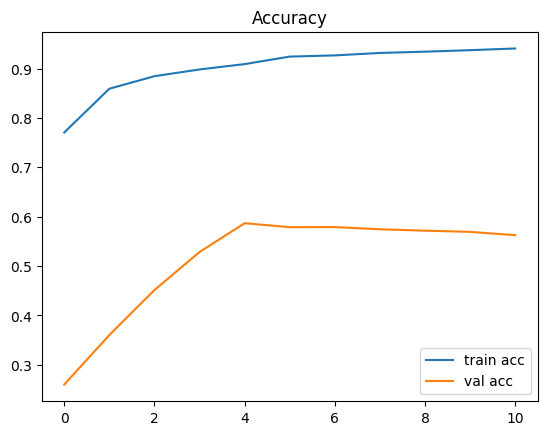

In [12]:
EPOCHS = 40

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5)
]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

plt.figure()
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Accuracy")
plt.show()


## 9) Evaluation
We report:
- Window-level metrics
- Device-level metrics via mean-probability aggregation over windows


Window-level classification report:
                       precision    recall  f1-score   support

 continuous_streaming     0.3982    0.2787    0.3279       800
interactive_actuators     0.5064    0.8850    0.6442       400
   low_rate_telemetry     0.6977    0.0735    0.1330       408
  smart_media_clients     0.4792    0.7965    0.5984       462

             accuracy                         0.4710      2070
            macro avg     0.5204    0.5085    0.4259      2070
         weighted avg     0.4962    0.4710    0.4110      2070



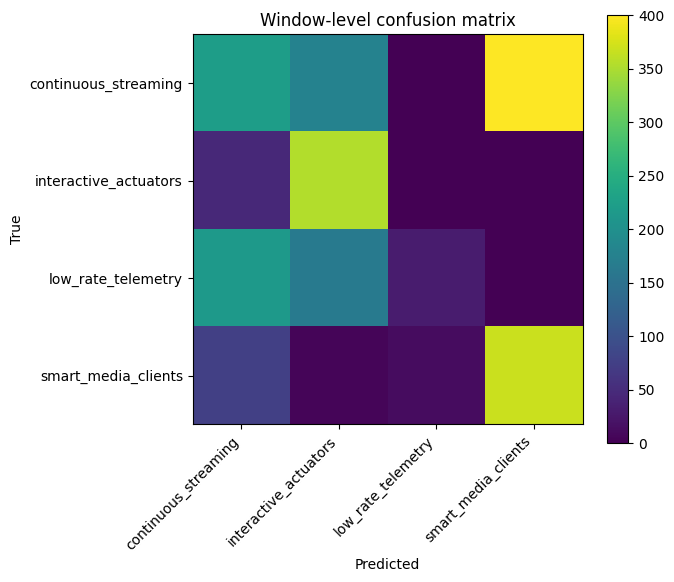


Per-device predictions:
- NestDropCam_308cfb2fe4b2            true=continuous_streaming   pred=smart_media_clients    windows=400
- PixStarPhotoFrame_e076d033bb85      true=smart_media_clients    pred=smart_media_clients    windows=400
- PhilipsHue_0017882b9a25             true=interactive_actuators  pred=interactive_actuators  windows=400
- BlipCareBPMeter_746a89002e25        true=low_rate_telemetry     pred=low_rate_telemetry     windows=8
- HelloBarbie_28c2ddffa52d            true=smart_media_clients    pred=continuous_streaming   windows=62
- WithingsSmartScale_0024e41b6f96     true=low_rate_telemetry     pred=continuous_streaming   windows=400
- SamsungCamera_00166cab6b88          true=continuous_streaming   pred=continuous_streaming   windows=400

Device-level classification report (mean-prob aggregation):
                       precision    recall  f1-score   support

 continuous_streaming     0.3333    0.5000    0.4000         2
interactive_actuators     1.0000    1.0000    1.

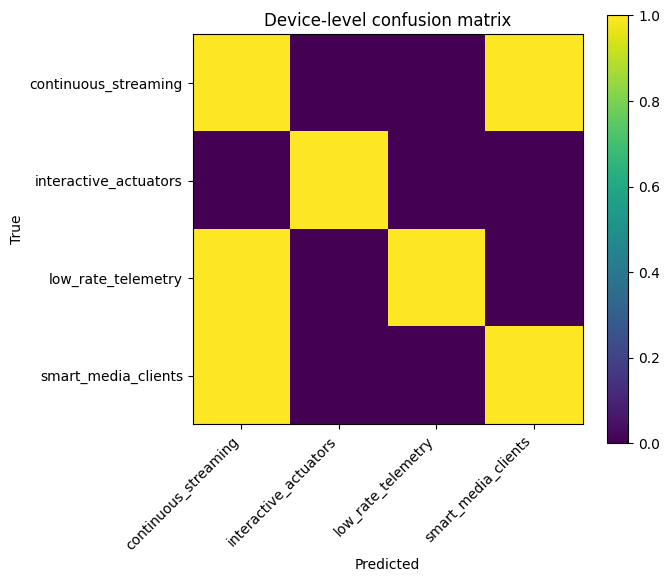

In [13]:
def collect_window_preds(df_sub: pd.DataFrame, model: tf.keras.Model, max_windows_per_device: int = 500):
    all_true = []
    all_pred = []
    per_device = []  # (device_id, y_true, probs_mean, y_pred, window_count)

    for _, row in df_sub.iterrows():
        dev = row["device_id"]
        y_true = int(row["y"])
        pcap_path = row["pcap_path"]
        device_ip = infer_device_ip(pcap_path, scan_packets=200)

        probs = []
        wcount = 0
        for Xs, ys in iter_summary_windows(pcap_path, device_ip=device_ip, label=y_true, max_windows=max_windows_per_device):
            p = model.predict(Xs[None, ...], verbose=0)[0]
            probs.append(p)
            y_hat = int(np.argmax(p))
            all_true.append(y_true)
            all_pred.append(y_hat)
            wcount += 1

        if probs:
            probs_mean = np.mean(np.stack(probs, axis=0), axis=0)
            y_dev = int(np.argmax(probs_mean))
        else:
            probs_mean = np.zeros((n_classes,), dtype=np.float32)
            y_dev = -1

        per_device.append((dev, y_true, probs_mean, y_dev, wcount))

    return np.array(all_true), np.array(all_pred), per_device

win_true, win_pred, dev_preds = collect_window_preds(test_df, model, max_windows_per_device=400)

print("Window-level classification report:")
print(classification_report(win_true, win_pred, target_names=types, digits=4))

cm = confusion_matrix(win_true, win_pred, labels=list(range(n_classes)))
plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Window-level confusion matrix")
plt.colorbar()
plt.xticks(range(n_classes), types, rotation=45, ha="right")
plt.yticks(range(n_classes), types)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Device-level aggregation
dev_true = []
dev_pred = []
print("\nPer-device predictions:")
for dev, y_true, probs_mean, y_dev, wcount in dev_preds:
    if y_dev >= 0:
        dev_true.append(y_true)
        dev_pred.append(y_dev)
    print(f"- {dev:35s} true={idx_to_type[y_true]:22s} pred={idx_to_type.get(y_dev,'(none)'):22s} windows={wcount}")

dev_true = np.array(dev_true)
dev_pred = np.array(dev_pred)

print("\nDevice-level classification report (mean-prob aggregation):")
print(classification_report(dev_true, dev_pred, target_names=types, digits=4))

cm2 = confusion_matrix(dev_true, dev_pred, labels=list(range(n_classes)))
plt.figure(figsize=(7, 6))
plt.imshow(cm2, interpolation="nearest")
plt.title("Device-level confusion matrix")
plt.colorbar()
plt.xticks(range(n_classes), types, rotation=45, ha="right")
plt.yticks(range(n_classes), types)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


## 10) Notes / knobs to tune
- `PKTS_PER_WINDOW`, `STRIDE`: summary-only often benefits from overlapping windows (e.g. stride 30)
- `BURST_GAP_SECONDS`: affects burst count; 0.2–1.0s are typical
- Add/remove `dns_like_ratio` and `tls_like_ratio` if you consider them too identifying

Next variants you asked for can reuse everything above:
- packet + summary (two-branch)
- summary + no direction
